In [ ]:
# Use the list of cities to create site inputs for openeo
# adding band math operations
# updated prepare_openeo.py, utlilities.py
# add fmi...

# RTS, May 16 - 19, 2025

In [57]:
# variables specific to your CoLabsetup ----------------------------------------
from google.colab import drive
import os, sys
drive.mount('/content/drive')
root = '/content/drive/MyDrive/'
sys.path.append(root +"Colab/research/code/")
datapath = root + "Colab/research/data/"
datapathnudge = root + "Projects/Nudge/geo_images/samples/"
datapathcities = root + "Projects/Nudge/sites/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
# install packages
%%capture
!pip install openeo --upgrade
!pip install gdal
!pip install rasterio --upgrade
!pip install scikit-image --upgrade

In [59]:
# additional imports
import openeo, json
import rasterio, numpy
from rasterio.plot import show
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap

# home brew
from prepare_openeo import *
from qualcheck_module import *
from utilities import *

In [60]:
collection = "Capital_Cities_with_Countries_and_Coordinates_update5.csv"
file_path = datapathcities + collection

In [61]:
def recompile(metadata):
  recompiled_metadata = {}
  for k in metadata['assets'].keys():
    recompiled_metadata[k] = {i['name']:i['statistics']['valid_percent'] for i in metadata['assets'][k]['raster:bands']}
  return recompiled_metadata

# Use Bands to filter!! like IR, then RGB, etc
def filter(lists, threshold=96.5):
  res = []
  for k,stats in lists.items():
    if min(stats.values()) > threshold:
      res.append(k)
  return (res)


In [62]:
# create the bboxes for openeo
# start with 3, then increase
import csv
j=0
limit = 3
bboxes = []
cities = []
try:
        with open(file_path, 'r') as file:
            csv_reader = csv.reader(file)
            next(csv_reader) # Skip the header row
            for row in csv_reader:
                city = row[0]
                latitude = float(row[2])
                longitude = float(row[3])
                bbox = get_coordinates(latitude,longitude,surface_area=100)
                #print(city, bbox)
                if(j < limit):
                    print(city, bbox)
                    bboxes.append(bbox)
                    cities.append(city)
                    j+=1
                else:
                    break
except FileNotFoundError:
        print(f"Error: File not found at '{file_path}'")

Tirana [19.75679780848154, 41.36163275029593, 19.876536191518458, 41.27170058970406]
Algiers [2.9938803540354892, 36.794966080295936, 3.1061196459645104, 36.705033919704064]
Buenos Aires [-58.72128378327733, -34.538367249704066, -58.612050216722665, -34.62829941029594]


In [63]:
# connect to the cdse backend
# marcbohlen@gmail	!2EU ... EU2!
connection = openeo.connect(url="openeo.dataspace.copernicus.eu")

#authenticate with your Copernicus credentials
connection.authenticate_oidc()
print()

Authenticated using refresh token.



In [66]:
# band operations
# https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel/sentinel-2/

satellite = "SENTINEL2_L1C"
max_cloud = 5
start = "2024-12-01"
end = "2024-12-31"
band_selection = ["B12", "B08", "B04", "B03", "B02"]

#OK
#aspect = "rgb"
#aspect = "ndvi"
#aspect = "nbr"
#aspect = "ndbi"
aspect = "fmi"

job_title = "nudge_" + aspect

In [69]:
## ------------------------------------------------------------------------------------------------------------------------------------------
# get just the first item and create a job for OpenEO
## ------------------------------------------------------------------------------------------------------------------------------------------
# create_job is part of the file "prepare_openeo.py" in the code folder

bbox_s = bboxes[0]
city_s = cities[0]

print(job_title)
job = create_job_type(connection, bbox_s, start, end, satellite, band_selection, max_cloud, job_title, aspect)
print(connection.list_jobs())

nudge_ndbi
[{'created': '2025-05-19T23:40:27Z', 'id': 'j-2505192340274efd840c6dbf13e9c9aa', 'progress': 0, 'status': 'created', 'title': 'nudge_ndbi', 'updated': '2025-05-19T23:40:27Z'}, {'created': '2025-05-19T23:39:38Z', 'id': 'j-25051923393849d390d6a3f0f30861b0', 'status': 'running', 'title': 'nudge_ndbi', 'updated': '2025-05-19T23:40:05Z'}, {'created': '2025-05-19T23:38:48Z', 'id': 'j-2505192338484a8499b790e24aa1437c', 'progress': 0, 'status': 'created', 'title': 'nudge_nbr', 'updated': '2025-05-19T23:38:48Z'}, {'created': '2025-05-19T22:04:39Z', 'id': 'j-2505192204394c98a2d68916f6559824', 'progress': 100, 'status': 'finished', 'title': 'nudge_nbr', 'updated': '2025-05-19T22:07:10Z'}, {'created': '2025-05-19T21:38:43Z', 'id': 'j-25051921384345e988925b62b226219f', 'progress': 100, 'status': 'finished', 'title': 'nudge_nbr', 'updated': '2025-05-19T21:41:12Z'}, {'created': '2025-05-19T21:03:08Z', 'id': 'j-2505192103084e88bcaa5356b327bb0a', 'progress': 100, 'status': 'finished', 'title

In [70]:
try:
    job.start_and_wait()
except:
    print("something went wrong")

0:00:00 Job 'j-2505192340274efd840c6dbf13e9c9aa': send 'start'
0:00:13 Job 'j-2505192340274efd840c6dbf13e9c9aa': created (progress 0%)
0:00:19 Job 'j-2505192340274efd840c6dbf13e9c9aa': created (progress 0%)
0:00:25 Job 'j-2505192340274efd840c6dbf13e9c9aa': created (progress 0%)
0:00:33 Job 'j-2505192340274efd840c6dbf13e9c9aa': created (progress 0%)
0:00:43 Job 'j-2505192340274efd840c6dbf13e9c9aa': running (progress N/A)
0:00:56 Job 'j-2505192340274efd840c6dbf13e9c9aa': running (progress N/A)
0:01:11 Job 'j-2505192340274efd840c6dbf13e9c9aa': running (progress N/A)
0:01:30 Job 'j-2505192340274efd840c6dbf13e9c9aa': running (progress N/A)
0:01:54 Job 'j-2505192340274efd840c6dbf13e9c9aa': running (progress N/A)
0:02:24 Job 'j-2505192340274efd840c6dbf13e9c9aa': running (progress N/A)
0:03:02 Job 'j-2505192340274efd840c6dbf13e9c9aa': finished (progress 100%)


In [71]:
results = job.get_results()
metadata = results.get_metadata()
metadata['assets'].keys()

dict_keys(['openEO_2024-12-11Z.tif', 'openEO_2024-12-16Z.tif'])

In [72]:
compiled = recompile(metadata)
print(compiled)

res = filter(compiled)
print(res)

{'openEO_2024-12-11Z.tif': {'1': 100}, 'openEO_2024-12-16Z.tif': {'1': 100}}


In [74]:
# check the filtered list against the assets -
relevant_results = []

assets = results.get_assets()
for item in assets:
    for filtered in res:
        if(item.name == filtered):
            relevant_results.append(item)

# check
print(relevant_results)

[<ResultAsset 'openEO_2024-12-11Z.tif' (type image/tiff; application=geotiff) at 'https://openeo.dataspace.copernicus.eu/openeo/1.2/jobs/j-2505192340274efd840c6dbf13e9c9aa/results/assets/ZTJjNjI3YjktMWQxNS00NDZlLWE4NDMtOWU3ZWIzYjExMDhh/e2e2c8b0484df36b9a71bda939a21538/openEO_2024-12-11Z.tif?expires=1748303018'>, <ResultAsset 'openEO_2024-12-16Z.tif' (type image/tiff; application=geotiff) at 'https://openeo.dataspace.copernicus.eu/openeo/1.2/jobs/j-2505192340274efd840c6dbf13e9c9aa/results/assets/ZTJjNjI3YjktMWQxNS00NDZlLWE4NDMtOWU3ZWIzYjExMDhh/51ec8d8e698bb0787019eaaab29fcb56/openEO_2024-12-16Z.tif?expires=1748303018'>]


In [75]:
#download those files and name them based on image type (aspect in job_title), location and date
targets = []

for item in relevant_results:
    date = item.name.split("openEO_")[1]
    date = date.split("Z.tif")[0] + ".tif"
    if("rgb" in job_title):
        target = city_s + "_rgb_" + date
    elif("ndvi" in job_title):
        target = city_s + "_ndvi_" + date
    elif("nbr" in job_title):
        target = city_s + "_nbr_" + date
    elif("fmi" in job_title):
        target = city_s + "_fmi_" + date
    elif("ndbi" in job_title):
        target = city_s + "_ndbi_" + date
    else:
        target = city_s + "_" + date

    targets.append(target)
    item.download(datapathcities + target)

In [ ]:
# Check the quality of the downloaded assets first...Only for the RGB images... if it is ok, the others should be as well...
for thing in targets:
    stats = evaluate_image_quality (datapathcities + thing)
    print(stats)

{'contrast': np.float64(1.6284551278896553), 'entropy': np.float64(45.28542471868263), 'sharpness': np.float64(2.4951828773684808), 'noise': np.float64(97.23315871060676), 'overall': np.float64(36.660555358636884)}
{'contrast': np.float64(1.0632599742633244), 'entropy': np.float64(39.90764668953899), 'sharpness': np.float64(1.8268093920124382), 'noise': np.float64(98.00977071909813), 'overall': np.float64(35.20187169372822)}


In [76]:
# Pick one to the images to visualize here
# Make a loopt to process them all...


#file_path = datapathcities + targets[1]
file_path = datapathcities + targets[0]
png_output_path = datapathcities + targets[0].split(".tif")[0] + ".png"

In [82]:
# Adjust images based on image type for human consumption
# Send grayscale to MLLM

with rasterio.open(file_path) as src:
    if("rgb" in job_title):
        r = src.read(1).astype(numpy.float32)
        g = src.read(2).astype(numpy.float32)
        b = src.read(3).astype(numpy.float32)
        # Apply contrast stretching
        r = contrast_stretch(r)
        g = contrast_stretch(g)
        b = contrast_stretch(b)
        # Apply gamma
        r = apply_gamma(r)
        g = apply_gamma(g)
        b = apply_gamma(b)
        # Stack into RGB
        rgb = numpy.dstack((r, g, b))
        # Brightness
        rgb = boost_brightness(rgb, factor=1.2)
        # Sharpen
        rgb = sharpen(rgb)
        # Saturation
        rgb = adjust_saturation(rgb, factor=0.7)

    else:
        gray = src.read(1).astype(numpy.float32)
        # Normalize grayscale to [0,1]
        gray_min, gray_max = numpy.min(gray), numpy.max(gray)
        if gray_max > gray_min:
            gray_norm = (gray - gray_min) / (gray_max - gray_min)
        else:
            gray_norm = numpy.zeros_like(gray)

        # contrast stretch
        gray_norm = contrast_stretch(gray_norm)

        if("ndvi" in job_title):
            cmap = plt.get_cmap("RdYlGn")  # Red → Yellow → Green
        elif("nbr" in job_title):
            cmap = plt.get_cmap("RdBu")  # Red → Blue
        elif ("ndbi" in job_title):
            built_up = [
                [1, 1, 1],         #White
                [0.7, 0.7, 0.7],
                [0.6, 0.6, 0.6],
                [0.5, 0.5, 0.5],
                [0.4, 0.4, 0.4],
                [0.6, 0.3, 0.1],  #Brown
                ]
            cmap = ListedColormap(built_up)

        else:
            cmap = plt.get_cmap("gray")

        # Map grayscale to RGB
        rgb = cmap(gray_norm)[..., :3]  # discard alpha

Saved color-corrected PNG to: /content/drive/MyDrive/Projects/Nudge/sites/Tirana_ndbi_2024-12-11.png


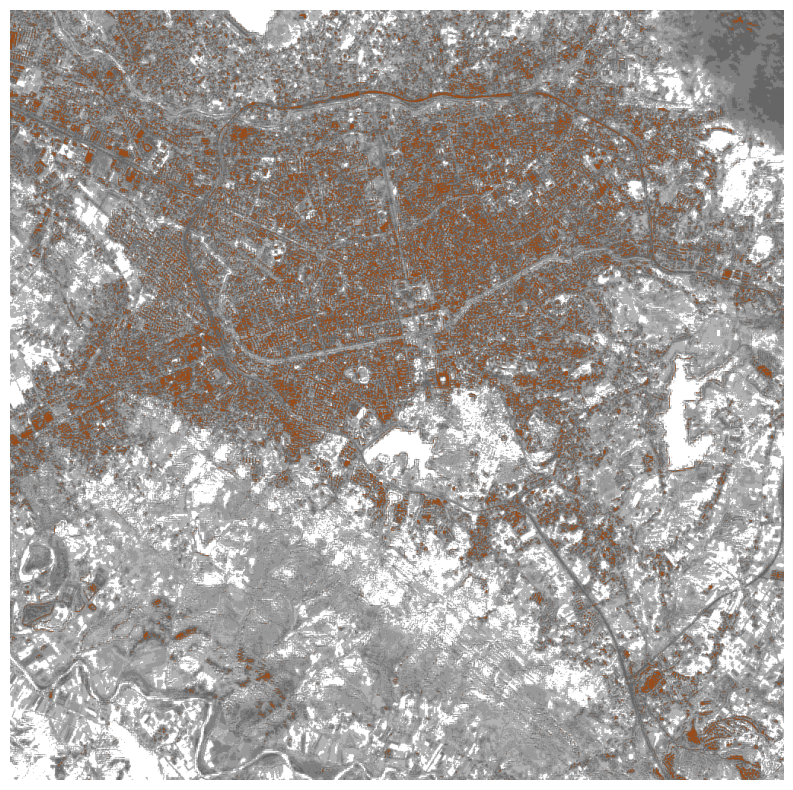

In [83]:
# RGB / NDVI / NBR
# Display and save using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(rgb)
#plt.imshow(rgb, vmin=-1, vmax=1)
#plt.title("Color-Corrected GeoTIFF (RGB) of " +  target)
plt.axis('off')
plt.savefig(png_output_path, bbox_inches='tight', pad_inches=0)
print(f"Saved color-corrected PNG to: {png_output_path}")